In [42]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [43]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimiseV2') # path to parent of output_root in set_parameters
study_prefix = 'optCombos-study2' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs/{study_prefix}') # path dir to save outputs in
suffixes = ['a', 'b', 'c'] # individual study identifier (end of dir name of output_root in set_parameters)

In [23]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
get_params3d(root_dir, study_prefix, suffixes).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [44]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [45]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

36


Highest element count:
	14874R - 1113615


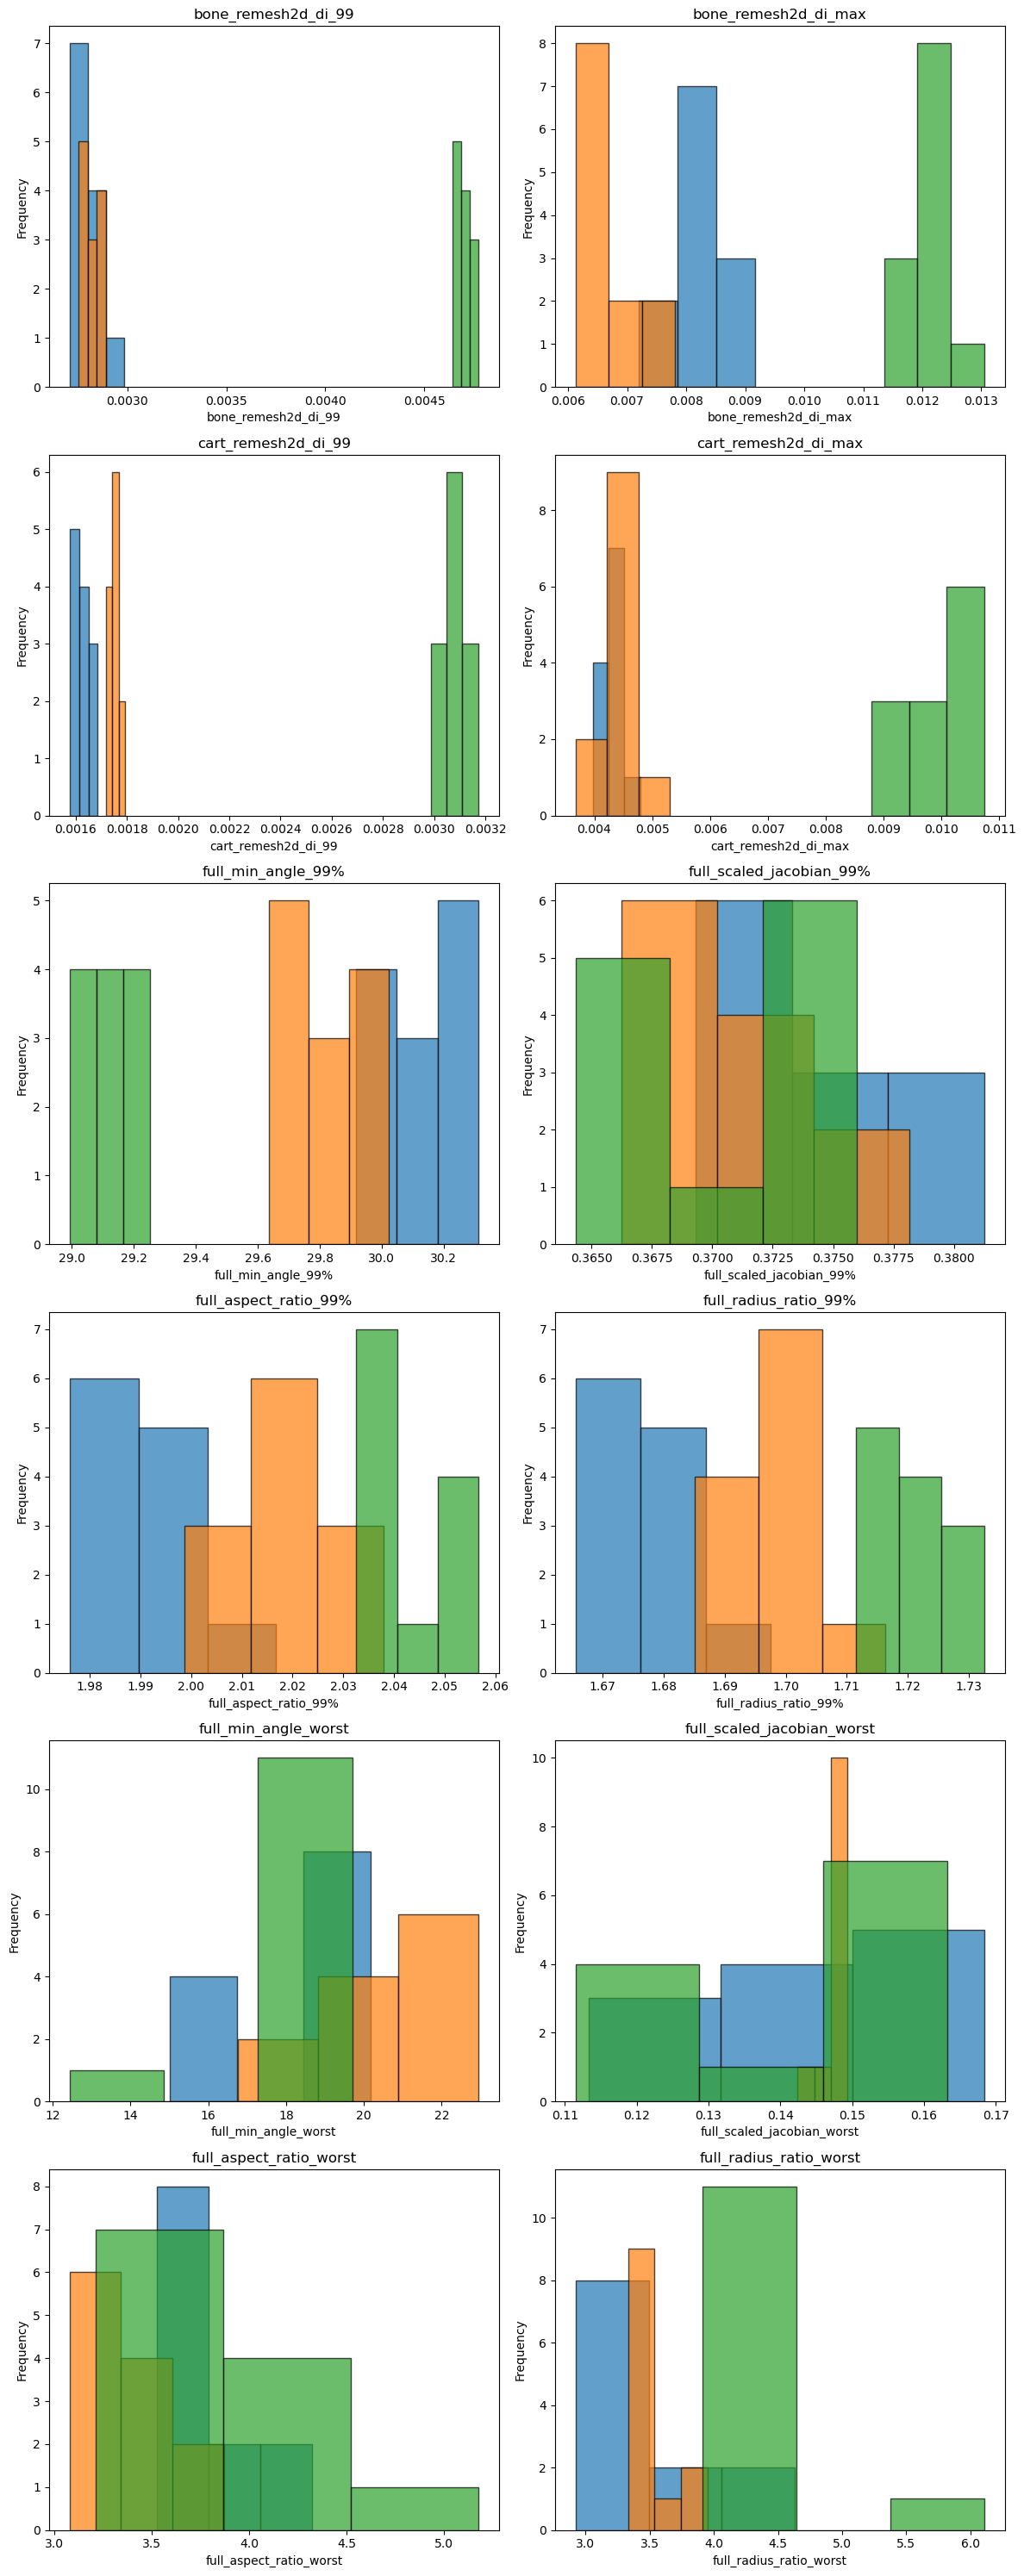

In [46]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [47]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

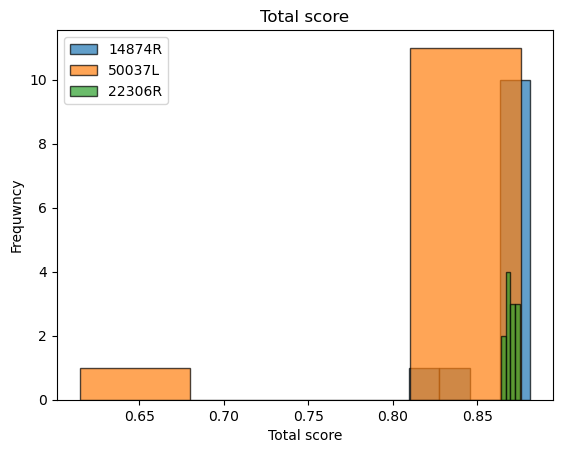

In [48]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [49]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,mean_rank,median_rank,best_rank,n_runs
1,15,0.0005,2.666667,2.0,1.0,3
4,30,0.0005,3.333333,3.0,1.0,3
2,15,0.0010,3.666667,4.0,1.0,3
0,15,0.0001,4.333333,4.0,3.0,3
3,30,0.0001,5.666667,7.0,2.0,3
6,45,0.0001,5.666667,5.0,5.0,3
5,30,0.0010,7.333333,9.0,3.0,3
10,100,0.0005,7.333333,8.0,2.0,3
11,100,0.0010,8.000000,9.0,4.0,3
8,45,0.0010,9.333333,9.0,8.0,3


In [50]:
sub = '50037L'
df_score_param[(df_score_param['sub']==sub)][[x for x in df_score_param.columns if 'worst' not in x]].head(5)

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,total,rank_within_case,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound
3,50037L,tpm,0-0-4-0c,0.975054,0.863672,1.0,1.0,0.875552,1.0,30,0.0005
4,50037L,tpm,0-0-5-0c,0.974993,0.863047,1.0,1.0,0.875467,2.0,30,0.0001
5,50037L,tpm,0-0-3-0c,0.973580,0.863727,1.0,1.0,0.875387,3.0,30,0.0010
11,50037L,tpm,0-0-2-0c,0.971706,0.879909,1.0,1.0,0.871704,4.0,15,0.0001
12,50037L,tpm,0-0-1-0c,0.970859,0.879688,1.0,1.0,0.871571,5.0,15,0.0005


In [51]:
sub = '22306R'
df_score_param[(df_score_param['sub']==sub)][[x for x in df_score_param.columns if 'worst' not in x]].head(5)

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,total,rank_within_case,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound
7,22306R,tpm,0-0-0-0b,0.998630,0.890738,1.0,1.0,0.874834,1.0,15,0.0010
8,22306R,tpm,0-0-1-0b,0.995222,0.885592,1.0,1.0,0.873765,2.0,15,0.0005
10,22306R,tpm,0-0-4-0b,1.000000,0.870723,1.0,1.0,0.872503,3.0,30,0.0005
15,22306R,tpm,0-0-9-0b,1.000000,0.854898,1.0,1.0,0.870525,4.0,100,0.0010
16,22306R,tpm,0-0-8-0b,0.997297,0.854536,1.0,1.0,0.870142,5.0,45,0.0001


In [61]:
sub = '14874R'
df_score_param[(df_score_param['sub']==sub)][[x for x in df_score_param.columns if 'worst' not in x]].head(10)

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,total,rank_within_case,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound
0,14874R,tpm,0-0-1-0a,1.000000,0.905682,1.0,1.0,0.881324,1.0,15,0.0005
1,14874R,tpm,0-0-10-0a,1.000000,0.853354,1.0,1.0,0.880868,2.0,100,0.0005
2,14874R,tpm,0-0-2-0a,1.000000,0.906260,1.0,1.0,0.879219,3.0,15,0.0001
6,14874R,tpm,0-0-0-0a,0.997208,0.887864,1.0,1.0,0.875131,4.0,15,0.0010
9,14874R,tpm,0-0-8-0a,1.000000,0.868566,1.0,1.0,0.873257,5.0,45,0.0001
14,14874R,tpm,0-0-4-0a,1.000000,0.876818,1.0,1.0,0.871294,6.0,30,0.0005
18,14874R,tpm,0-0-11-0a,1.000000,0.858762,1.0,1.0,0.869395,7.0,100,0.0001
22,14874R,tpm,0-0-5-0a,1.000000,0.881570,1.0,1.0,0.868028,8.0,30,0.0001
26,14874R,tpm,0-0-9-0a,1.000000,0.849471,1.0,1.0,0.866238,9.0,100,0.0010
27,14874R,tpm,0-0-3-0a,1.000000,0.863920,1.0,1.0,0.864672,10.0,30,0.0010


In [62]:
df_score_qual[(df_score_qual['sub']==sub)][['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if '_y' in x]].head(10)

,sub,bone,run_id,full_min_angle_worst_y,full_min_angle_99%_y,full_radius_ratio_worst_y,full_radius_ratio_99%_y,full_aspect_ratio_worst_y,full_aspect_ratio_99%_y,full_scaled_jacobian_worst_y,full_scaled_jacobian_99%_y
0,14874R,tpm,0-0-1-0a,20.132961,30.174507,2.921388,1.684591,3.527325,2.000853,0.158718,0.381136
1,14874R,tpm,0-0-10-0a,20.132961,30.228023,3.113839,1.666521,3.527325,1.976539,0.168371,0.370671
2,14874R,tpm,0-0-2-0a,20.132961,30.178197,2.921388,1.683950,3.527325,1.999602,0.154448,0.381252
6,14874R,tpm,0-0-0-0a,16.006585,29.916247,4.094812,1.697513,3.979424,2.016773,0.162716,0.377573
9,14874R,tpm,0-0-8-0a,20.132961,30.274284,2.921388,1.667345,3.527325,1.977855,0.151724,0.373713
14,14874R,tpm,0-0-4-0a,20.002319,30.212378,3.113839,1.675861,3.549189,1.988618,0.144124,0.375364
18,14874R,tpm,0-0-11-0a,20.164296,30.247508,2.921388,1.665589,3.527325,1.976012,0.145129,0.371752
22,14874R,tpm,0-0-5-0a,20.164296,30.311462,3.009690,1.672488,3.527325,1.984481,0.130769,0.376314
26,14874R,tpm,0-0-9-0a,20.132961,30.151657,2.921388,1.671729,3.527325,1.981854,0.139094,0.369894
27,14874R,tpm,0-0-3-0a,15.996101,30.035663,3.609642,1.683569,4.044219,2.000527,0.137011,0.372784


# Thoughts
 - very slight improvement for 50017L 
    - so not worth investigating more
 - 22306R and 14874R saw the same ~20% improvement to min_angle
---
### Best params
ODT - all exited due to hitting max iterations (4)
 - freeze_bound = 0.005
 - 15 -> 30 iterations
    - 2 prefer so 20?

---

### Plan
 - runs with all meshes for combos of:
     - d0 = [2, 4, 6]
         - Know that 6 is good enough so check smaller values to see try and lower element count
         - look at convergence of overall mesh quality as d0 increases to see how much it helps
     - p_h = [3, 6, 9, 12]
         - Have seen that the range of geometries in the database give good values in this range
         - any higher and it just becomes vertical wall so no point
             - also lower means tapers quicker and lower cell count
     - taper_size = [0.2, 0.3, 0.4]
        - Know that 0.2 to 0.4 gives reasonable values for the range of geometries (StMmLt) 
         - don't want to go lower cos it increases cell count 
         - can't go higher cos cartilage height is only ~0.5 in this region so would demand poorer qaulity cells or large deviation from input surface for thinner cartilage subjects.

In [4]:
import pyvista as pv

L = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/ParamOptimisation/optimiseV2/optCombos-study2c/meshes/50037L/tpm-mc1/3Dmesh/mesh-0-0-1.vtu')
M = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/ParamOptimisation/optimiseV2/optCombos-study2b/meshes/22306R/tpm-mc1/3Dmesh/mesh-0-0-1.vtu')
S = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/ParamOptimisation/optimiseV2/optCombos-study2a/meshes/14874R/tpm-mc1/3Dmesh/mesh-0-0-1.vtu')


In [8]:
M.plot()

Widget(value='<iframe src="http://localhost:64010/index.html?ui=P_0x33158c380_3&reconnect=auto" class="pyvista…

# Facet distance to prevent edge holes
 - Need to check it doesn't affect quality much

In [75]:
import subprocess

path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/optCombos-study2/FD/params/full_params-12.json

SUBJECT: 22306R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.506s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.474s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 55.745s - ok
			RUN ID: -0-0-1
			Runtime: 51.996s - ok
			RUN ID: -0-0-2
			Runtime: 50.325s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [78]:
import pyvista as pv
sub = '22306R'
id_3d = 1
fd_path = f'outputs/optCombos-study2/FD/meshes/{sub}/tpm-mc1/3Dmesh/mesh-0-0-{id_3d}.vtu'

mesh = pv.read(fd_path)
mesh.plot()

Widget(value='<iframe src="http://localhost:64362/index.html?ui=P_0x3d564fc80_30&reconnect=auto" class="pyvist…

# Thoughts
 - Turns out the holes can be caused by odt when the size of the element is close to the thickness of the cartilage
 - Even with odt = False, can stil get significant holes around the edge if cell size is too large
    - need taper_size ≤ 0.25 to prevent edge holes
#### 22306R
 - FD's = [0.025, 0.05, 0.075] still result in holes around the edge
     - think it's due to the large taper_size = 0.4
     - use the FD ≥ 0.075 as example in write up
 - Can set FD = 0.5 and taper_size = 0.25 and theres no holes
- So it's taper size that really matters.

#### 14874R
 - Bad quality for taper_size = [0.2, 0.25],  FD = 0.50
 - Bad quality for most parameters except all the ones that happened to be tried in this study...

---
### Plan
 - Go ahead with geomCombos study but limit taper size to < 0.4 cos it eats away at the edges
    - want taper_size to be large to reduce cell count, but large eats edges and means faster transition for cartilage region
    - Need to check eges for all subjects
 - Include ODT = False

In [74]:
q = check_mesh_quality(mesh.extract_cells_by_type(10), 'tet')
mesh_quality_summary(q, 'tet')

radius_ratio 1/314556 cells outside of acceptable range (1.0, 3.0)
aspect_ratio 3/314556 cells outside of acceptable range (1.0, 3.0)
scaled_jacobian 13/314556 cells outside of acceptable range (0.2, 1.0)
aspect_frobenius 12/314556 cells outside of acceptable range (1.0, 2.0)


,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,50.692048,70.034895,21.015180,"(10, 70.53)",100.000000,0,"(35.83, 70.03)"
max_angle,94.114257,71.148044,147.535984,"(70.53, 170)",100.000000,0,"(71.15, 116.31)"
radius_ratio,1.163704,1.000287,3.004823,"(1.0, 3.0)",99.999682,1,"(1.0, 1.43)"
shape,0.888805,0.999756,0.435922,"(0.4, 1.0)",100.000000,0,"(0.74, 1.0)"
aspect_ratio,1.335567,1.009487,3.150395,"(1.0, 3.0)",99.999046,3,"(1.01, 1.7)"
scaled_jacobian,0.717927,0.992478,0.148022,"(0.2, 1.0)",99.995867,13,"(0.48, 0.99)"
aspect_frobenius,1.134212,1.000244,2.293988,"(1.0, 2.0)",99.996185,12,"(1.0, 1.35)"
condition,1.144128,1.000245,2.754538,"(1.0, 3.0)",100.000000,0,"(1.0, 1.39)"
